<a href="https://colab.research.google.com/github/Emblogs/House_Price_Project/blob/master/House_Price_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
!pip install category_encoders

In [42]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from category_encoders import MEstimateEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [43]:
train_data = pd.read_csv('/content/drive/MyDrive/House_Prices_Project/train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/House_Prices_Project/test.csv')

In [44]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [45]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


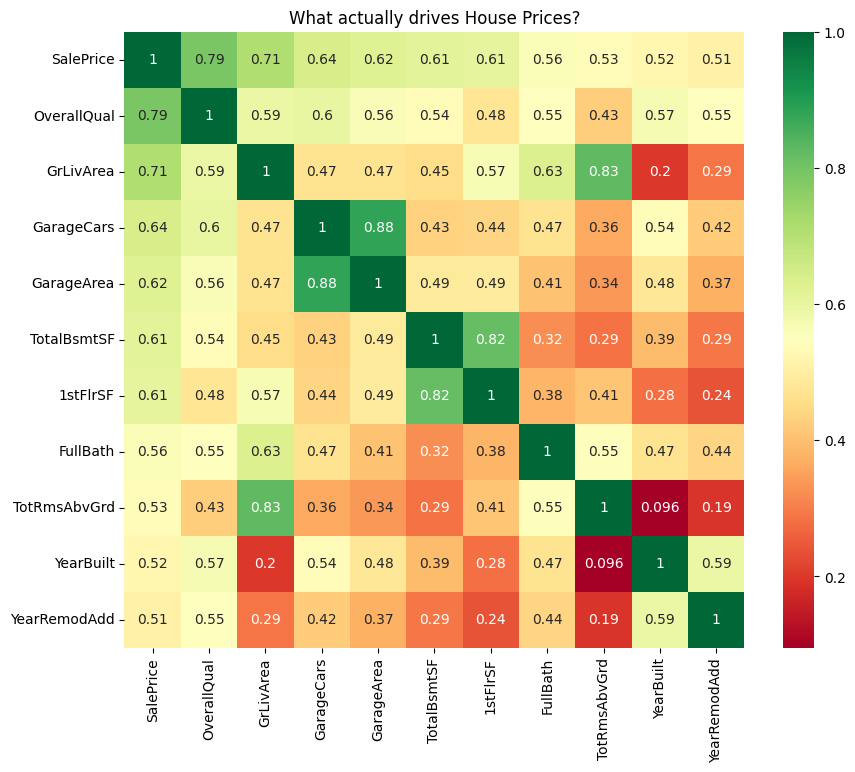

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the most important numerical features
correlations = train_data.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

# Visualize the top 10
plt.figure(figsize=(10, 8))
sns.heatmap(train_data[correlations.index[:11]].corr(), annot=True, cmap='RdYlGn')
plt.title("What actually drives House Prices?")
plt.show()

In [47]:
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
            '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd',
            'Neighborhood', 'KitchenQual']

X = train_data[features].copy()
y = train_data['SalePrice']

X['TotalSF'] = X['1stFlrSF'] + X['TotalBsmtSF'] + X['GrLivArea']
quality_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
X['KitchenQual'] = X['KitchenQual'].map(quality_map).fillna(2)

In [48]:
numerical_features = ['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', '1stFlrSF',
                      'YearBuilt', 'YearRemodAdd', 'GarageCars', 'FullBath', 'TotRmsAbvGrd', 'KitchenQual']

preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy='median'), numerical_features),
    ("geo", MEstimateEncoder(m=5.0), ['Neighborhood'])
])

numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps=[
    ("impute",SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown="ignore"))
])

In [49]:
# 1. Split
from sklearn.model_selection import train_test_split

# Standardizing names to X_train and X_valid
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

# Create the log targets cleanly
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

# 2. Preprocess
# Using the clean X_train and passing the log target for target encoding
X_train_prepped = preprocessor.fit_transform(X_train, y_train_log)
X_valid_prepped = preprocessor.transform(X_valid)

In [50]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 3. Define the XGBoost Model
model = XGBRegressor(n_estimators=2000,
                     learning_rate=0.01,
                     max_depth=4,
                     early_stopping_rounds=10)

# 4. Fit the model using the LOG target variables
model.fit(X_train_prepped, y_train_log,
          eval_set=[(X_valid_prepped, y_valid_log)],
          verbose=False)

# 5. Get your predictions (currently in log format)
preds_log = model.predict(X_valid_prepped)

# Convert predictions back to normal dollar amounts
preds = np.expm1(preds_log)

# 6. Calculate and print your score
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_valid, preds)

print("="*30)
print(f" Final Validation MAE: ${mae:,.2f}")
print(f" Best Training Iteration: {model.best_iteration}")
print("="*30)

# Optional: Let's see a quick comparison of actual vs predicted prices
comparison_df = pd.DataFrame({'Actual Price': y_valid, 'Predicted Price': preds})
print("\nFirst 5 Prediction Examples:")
print(comparison_df.head().round(2))

 Final Validation MAE: $18,856.64
 Best Training Iteration: 398

First 5 Prediction Examples:
     Actual Price  Predicted Price
529        200624    259603.406250
491        133000    140112.390625
459        110000    117018.781250
279        192000    233830.546875
655         88000     96569.101562
